# 1. Business understanding

Phising sites becoming more and more rampant as time goes on, we want to train a decision tree and random forest that can predict if a site is phising site or not.

## 2. Data Understanding

For training we are using dataset found here https://archive.ics.uci.edu/dataset/327/phishing+websites .  

The dataset has 11055 entries with no missing values and 30 features. The documentation for the dataset on the UCI site is inadequate, however the [this](https://arxiv.org/pdf/2101.02552) article states that  

`1 = legitimate`  
`0 = suspicious`  
`-1 = phishing`  

From `head()` method we can see that the data is already normalized using the same values as class.

### Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

## Load data

In [2]:
phishing_websites = fetch_ucirepo(id=327) 
  
X = phishing_websites.data.features 
y = phishing_websites.data.targets 
  
print(phishing_websites.metadata) 
print(phishing_websites.variables)

{'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey', 'venue': 'International Conference for Internet Tec

## Basic information

In [3]:
X.info()
X.describe()
X.dtypes
X.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   having_ip_address           11055 non-null  int64
 1   url_length                  11055 non-null  int64
 2   shortining_service          11055 non-null  int64
 3   having_at_symbol            11055 non-null  int64
 4   double_slash_redirecting    11055 non-null  int64
 5   prefix_suffix               11055 non-null  int64
 6   having_sub_domain           11055 non-null  int64
 7   sslfinal_state              11055 non-null  int64
 8   domain_registration_length  11055 non-null  int64
 9   favicon                     11055 non-null  int64
 10  port                        11055 non-null  int64
 11  https_token                 11055 non-null  int64
 12  request_url                 11055 non-null  int64
 13  url_of_anchor               11055 non-null  int64
 14  links_in_tags    

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,-1,-1,0,-1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,1,0,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,-1,1,-1,-1,0,-1,1,1,1
5,-1,0,-1,1,-1,-1,1,1,-1,1,...,1,1,1,1,1,1,-1,1,-1,-1
6,1,0,-1,1,1,-1,-1,-1,1,1,...,1,1,1,1,-1,-1,-1,1,0,-1
7,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,0,-1,1,0,1
8,1,0,-1,1,1,-1,1,1,-1,1,...,1,1,1,1,-1,1,1,1,0,1
9,1,1,-1,1,1,-1,-1,1,-1,1,...,1,1,1,1,-1,0,-1,1,0,1


# 3. Data Preparation

## Check missing values

In [4]:
print('Missing values in features:')
print('')
display(X.isnull().sum())

print('')

print('Sum of missing values in targets:')
print('')
print(y.isnull().sum().sum())

Missing values in features:



having_ip_address             0
url_length                    0
shortining_service            0
having_at_symbol              0
double_slash_redirecting      0
prefix_suffix                 0
having_sub_domain             0
sslfinal_state                0
domain_registration_length    0
favicon                       0
port                          0
https_token                   0
request_url                   0
url_of_anchor                 0
links_in_tags                 0
sfh                           0
submitting_to_email           0
abnormal_url                  0
redirect                      0
on_mouseover                  0
rightclick                    0
popupwindow                   0
iframe                        0
age_of_domain                 0
dnsrecord                     0
web_traffic                   0
page_rank                     0
google_index                  0
links_pointing_to_page        0
statistical_report            0
dtype: int64


Sum of missing values in targets:

0


## Renaming and making class categorical

Lets rename the classes to more descriptive than 1 and -1

In [5]:
y = y.replace({1: 'Legitimate', -1: 'Phishing'}).astype('category')

# 4. Modeling

Splitting data to test and train data:
 - Test 25%
 - Train 75%

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8291, 30) (2764, 30) (8291, 1) (2764, 1)


## Evaluating Decision Tree

Trying out 25 `max_depth` values in range 1-25 with for loop, we can see that theres only minor increase after
`max_depth=15`
so lets choose that for model evaluation

In [10]:
depth_results = []

for max_depth in range(1,26):
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=20)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    depth_results.append({
        "max depth": max_depth,
        "leaf nodes": model.get_n_leaves(),
        "accuracy": accuracy_score(y_test, y_pred),
    
        "Phishing precision": precision_score(y_test, y_pred, pos_label='Phishing'),
    
        "Phishing recall": recall_score(y_test, y_pred, pos_label='Phishing'),
    
        "Phishing f1-score": f1_score(y_test, y_pred, pos_label='Phishing')
    })

depth_results_df = pd.DataFrame(depth_results)

display(depth_results_df.round(4))

,max depth,leaf nodes,accuracy,Phishing precision,Phishing recall,Phishing f1-score
0,1,2,0.8904,0.8802,0.8663,0.8732
1,2,4,0.9070,0.8809,0.9095,0.8950
2,3,7,0.9081,0.8831,0.9095,0.8961
3,4,12,0.9175,0.9026,0.9086,0.9056
4,5,20,0.9255,0.9536,0.8713,0.9106
5,6,33,0.9352,0.9239,0.9277,0.9258
6,7,54,0.9392,0.9317,0.9286,0.9301
7,8,80,0.9418,0.9271,0.9402,0.9336
8,9,118,0.9486,0.9331,0.9502,0.9416
9,10,167,0.9526,0.9430,0.9485,0.9458


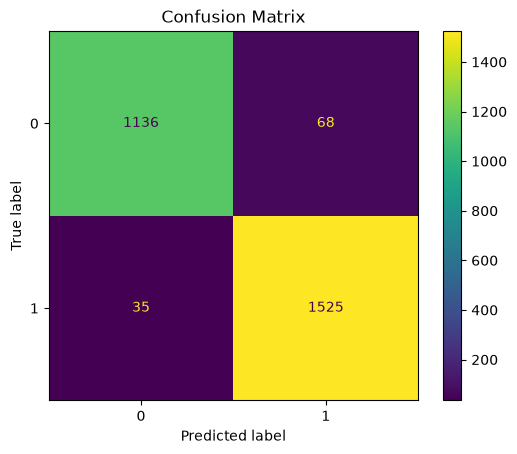

              precision    recall  f1-score   support

  Legitimate       0.96      0.98      0.97      1560
    Phishing       0.97      0.94      0.96      1204

    accuracy                           0.96      2764
   macro avg       0.96      0.96      0.96      2764
weighted avg       0.96      0.96      0.96      2764



In [22]:
model_tree = DecisionTreeClassifier(max_depth=15, random_state=20)
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=['Phishing', 'Legitimate'])

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

## Visualizing the Tree

With coloring the tree is clearer. Orange and other warm colors means phishing and cooler colors such as blue means legitimate

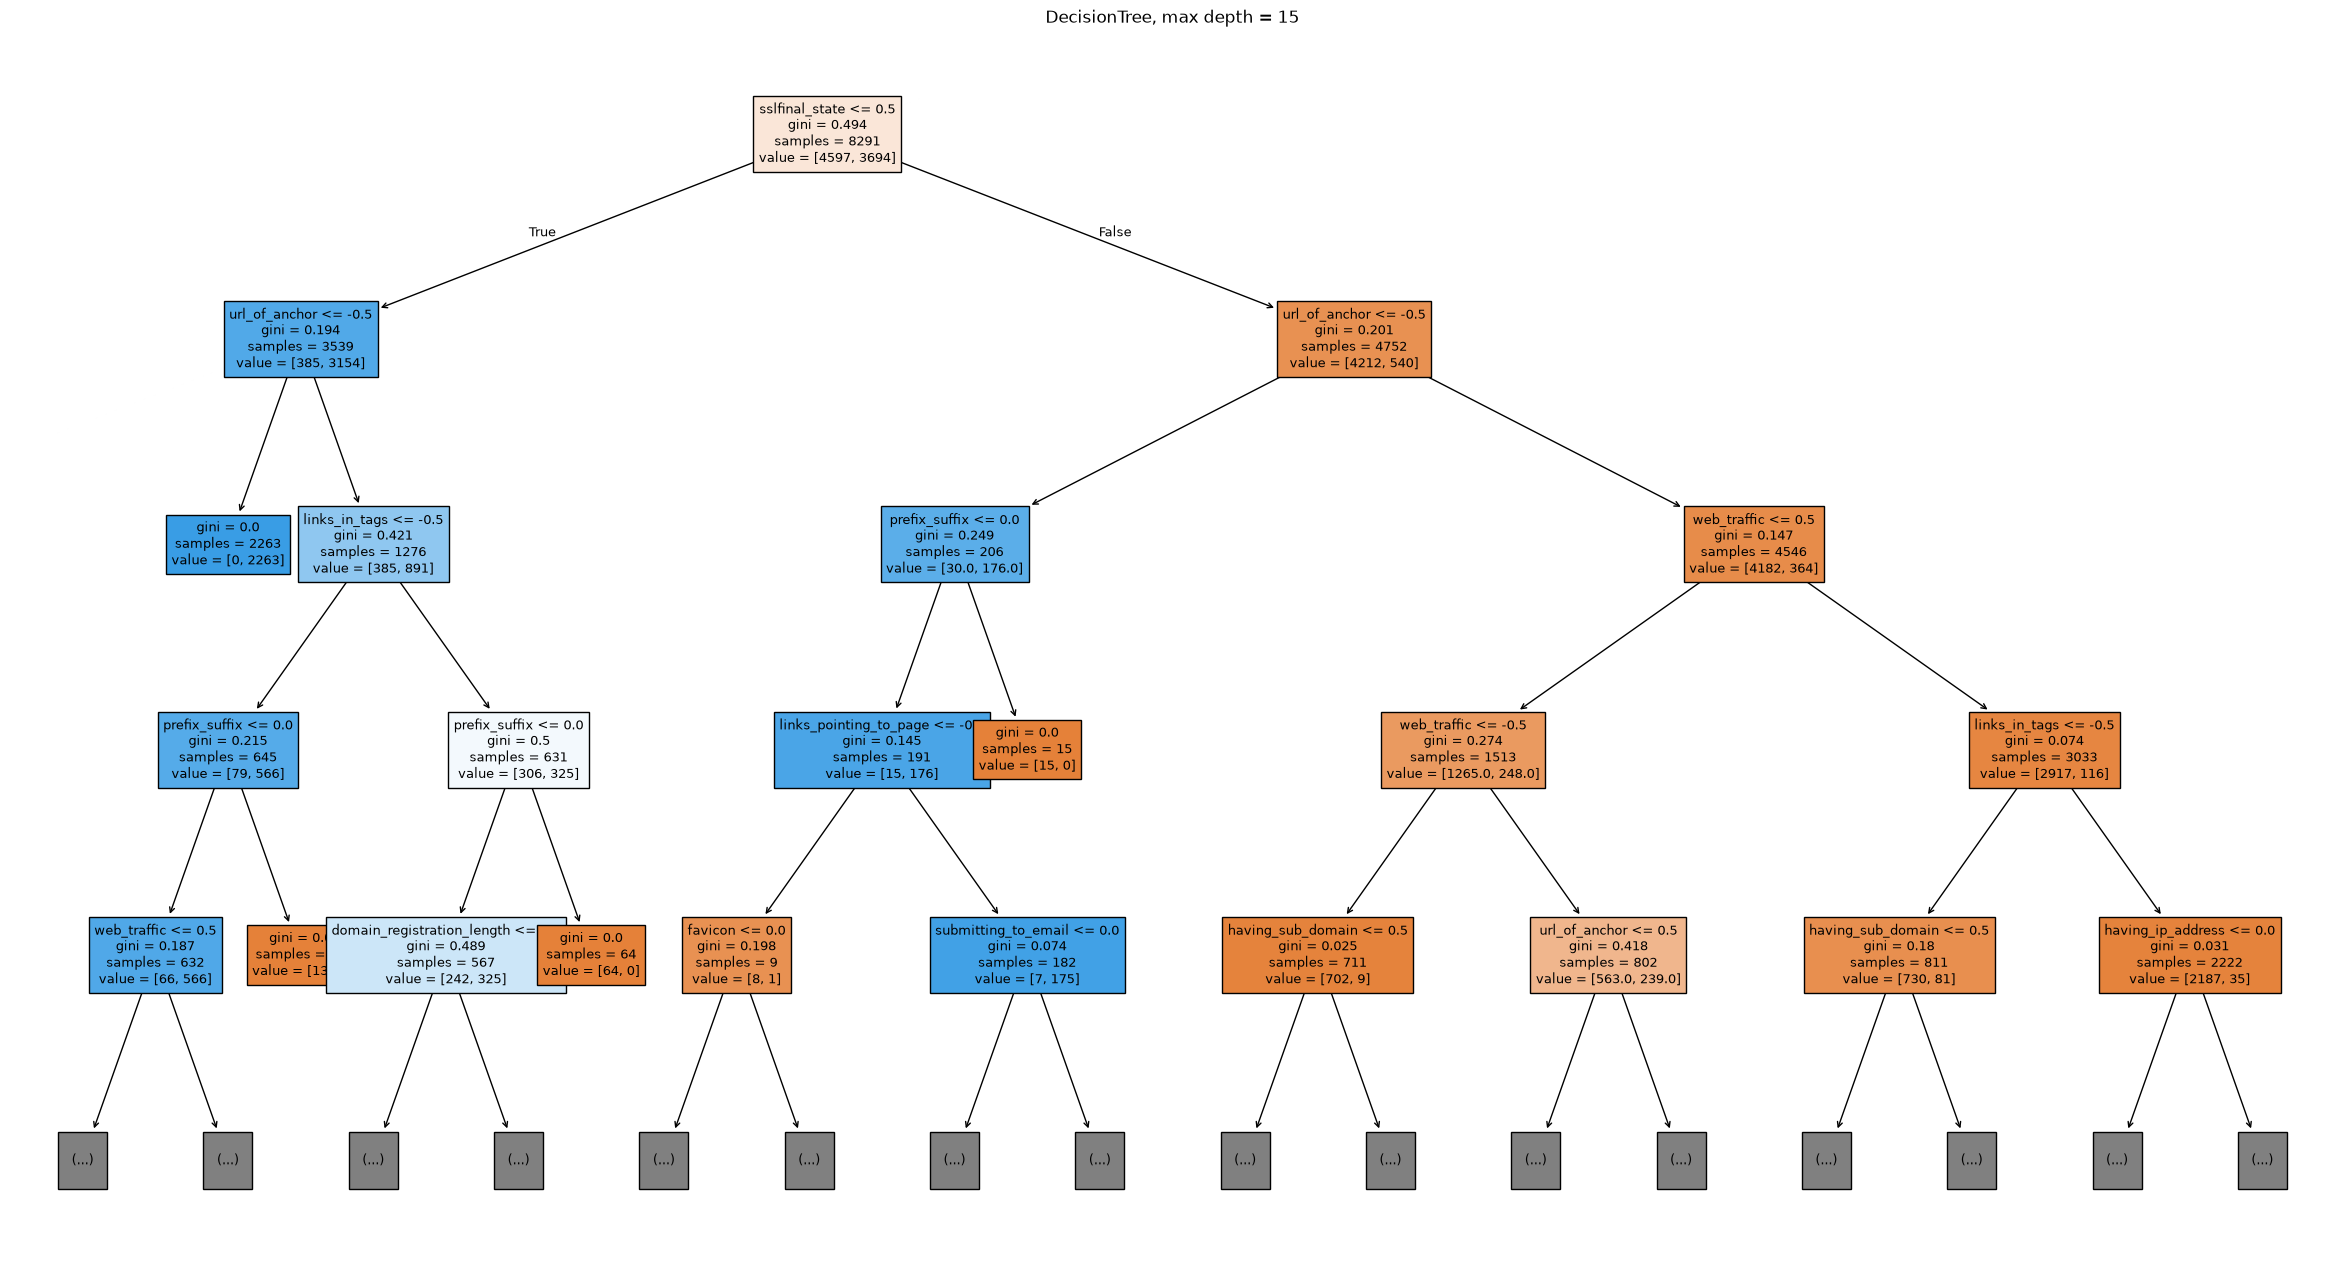

In [34]:
plt.figure(figsize=(30, 16))

plot_tree(
    model_tree,
    feature_names=X.columns,
    filled=True,
    max_depth=4,
    fontsize=9
)

plt.title("DecisionTree, max depth = 15, first 4 levels")

plt.show()

## Evaluating Random Forest

For random forests lets use the same max depth we found enough for decision tree, also same random state to keep results consistent, have to `squeeze()`y_train due to an error with it expecting 1 dimensional array

### Selecting Random Forest Parameters

Selecting the best parameters for the model:

- `max_samples` values: 0.6, 0.65, 0.7, 0.75, 0.8, 0.85
- `max_features` values: 0.3, 0.5, 0.7, 0.75, 1.0

In [19]:
max_samples_values = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85]
max_features_values = [0.3, 0.5, 0.7, 0.75, 1.0]

results = []

for max_samples in max_samples_values:
    for max_features in max_features_values:
        model_forest = RandomForestClassifier(n_estimators=100, bootstrap=True, max_depth=15, max_samples=max_samples, max_features=max_features, random_state=123)
        
        cv_scores = cross_val_score(model, X_train, y_train.squeeze(), cv=10)
    
        results.append({
                "max_samples": max_samples,
                "max_features": max_features,
                "accuracy": cv_scores.mean()
            })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "accuracy",
        ascending=False
    )
)

,max_samples,max_features,accuracy
15,0.75,0.30,0.966109
5,0.65,0.30,0.965867
20,0.80,0.30,0.965867
25,0.85,0.30,0.964903
27,0.85,0.70,0.964902
10,0.70,0.30,0.964782
26,0.85,0.50,0.964661
18,0.75,0.75,0.964661
6,0.65,0.50,0.964661
16,0.75,0.50,0.964541


sss

In [37]:
forest_model = RandomForestClassifier(n_estimators=100, bootstrap=True, max_depth=15, max_samples= 0.75, max_features=0.30, random_state=123)

forest_model.fit(X_train, y_train.squeeze())

y_pred_forest = forest_model.predict(X_test)

In [38]:
accuracy_forest = accuracy_score(
    y_test,
    y_pred_forest
)

precision_forest = precision_score(
    y_test,
    y_pred_forest,
    pos_label="Phishing"
)

recall_forest = recall_score(
    y_test,
    y_pred_forest,
    pos_label="Phishing"
)

f1_forest = f1_score(
    y_test,
    y_pred_forest,
    pos_label="Phishing"
)

accuracy_tree = accuracy_score(
    y_test,
    y_pred
)

precision_tree = precision_score(
    y_test,
    y_pred,
    pos_label="Phishing"
)

recall_tree = recall_score(
    y_test,
    y_pred,
    pos_label="Phishing"
)

f1_tree = f1_score(
    y_test,
    y_pred,
    pos_label="Phishing"
)

print("Decision Tree model:")

print(f"Accuracy: {accuracy_tree:.4f}")
print(f"Phishing precision: {precision_tree:.4f}")
print(f"Phishing recall: {recall_tree:.4f}")
print(f"Phishing F1-score: {f1_tree:.4f}")

print("")

print("Random Forest model:")

print(f"Accuracy: {accuracy_forest:.4f}")
print(f"Phishing precision: {precision_forest:.4f}")
print(f"Phishing recall: {recall_forest:.4f}")
print(f"Phishing F1-score: {f1_forest:.4f}")

Decision Tree model:
Accuracy: 0.9627
Phishing precision: 0.9701
Phishing recall: 0.9435
Phishing F1-score: 0.9566

Random Forest model:
Accuracy: 0.9754
Phishing precision: 0.9773
Phishing recall: 0.9659
Phishing F1-score: 0.9716


In [39]:
print("Decision Tree:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=["Phishing", "Legitimate"]
    )
)

print("")

print("Random Forest:")
print(
    classification_report(
        y_test,
        y_pred_forest,
        labels=["Phishing", "Legitimate"]
    )
)

Decision Tree:
              precision    recall  f1-score   support

    Phishing       0.97      0.94      0.96      1204
  Legitimate       0.96      0.98      0.97      1560

    accuracy                           0.96      2764
   macro avg       0.96      0.96      0.96      2764
weighted avg       0.96      0.96      0.96      2764


Random Forest:
              precision    recall  f1-score   support

    Phishing       0.98      0.97      0.97      1204
  Legitimate       0.97      0.98      0.98      1560

    accuracy                           0.98      2764
   macro avg       0.98      0.97      0.97      2764
weighted avg       0.98      0.98      0.98      2764



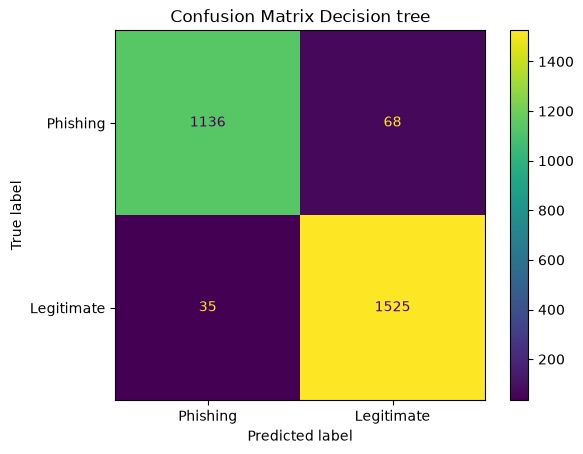

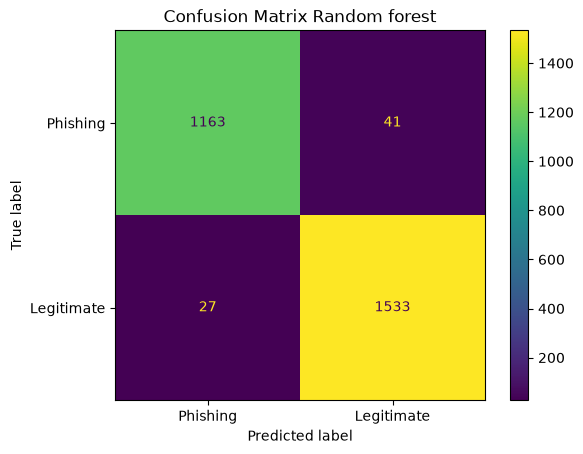

In [40]:
cm = confusion_matrix(y_test, y_pred, labels=["Phishing", "Legitimate"])

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Phishing",
        "Legitimate"
    ]
).plot()

plt.title("Confusion Matrix Decision tree")
plt.show()

cm_forest = confusion_matrix(y_test, y_pred_forest, labels=["Phishing", "Legitimate"])

ConfusionMatrixDisplay(
    confusion_matrix=cm_forest,
    display_labels=[
        "Phishing",
        "Legitimate"
    ]
).plot()

plt.title("Confusion Matrix Random forest")
plt.show()

# 5. Evaluation

From the results we can see that there was minor imporovements in precision and recall, true positives and negatives went up and false positives and negatives went down. However there is still some classified wrong.

## 6. Deployment

### Results

- **What did we find?**  
  We found that random forest gives higher accuracy, recall and precision in identifying phishing sites compared to decision tree, but the difference is minimal from our dataset.

- **How accurate was the model?**  
  Every metric commonly used for measure accuracy would point to the model being accurate.

- **Did we solve the original problem?**  
  Yes, we trained a high accuracy decision tree classifier and converted that to random forest to get even higher accuracy.

The model could be deployed in as real world application, however we'd want to have user reporting to catch false positives and negatives and potentially improve the model.